<a href="https://colab.research.google.com/github/Primz007/demand-forecasting-pipeline/blob/main/Demand_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

## 1. Data Loading & Exploration

In [ ]:
train=pd.read_csv('/content/drive/MyDrive/Demand Dataset/train.csv/train.csv')
print('-----------------------------------------')
print(train.head())
print('-----------------------------------------')                       # Basic info of dataset
print(train.shape)
print('-----------------------------------------')
print(train.info())


-----------------------------------------
   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False
-----------------------------------------
(421570, 5)
-----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB
None


In [ ]:
print(train['Store'].nunique(), "Stores")             # To see different types of stores and departments in dataset
print(train['Dept'].nunique(),'Departments')
print(train['Date'].min(),'to',train['Date'].max())

45 Stores
81 Departments
2010-02-05 to 2012-10-26


In [ ]:
train.isnull().sum()  # To see if there is any null values-> No null values

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0


##2. Selecting a Series (Store-Dept combo)
Since each Store-Dept combination is its own independent time series, we
first isolate one clean, complete series to build the pipeline on before
considering scaling to multiple series. Filtered to combinations with all
143 weeks present (no gaps), then manually inspected a few for seasonal
structure — Store 1, Dept 1 was selected for its clear, consistent yearly
seasonality.

In [ ]:
combo_counts=train.groupby(['Store','Dept']).size().reset_index(name='Count')

total_weeks=train['Date'].nunique()
print("Total number of weeks",total_weeks)

complete_combo=combo_counts[combo_counts['Count']==total_weeks]   # We will only consider those store which has no gaps in between
print('Number of complete combos: ',len(complete_combo))
print(complete_combo.head(10))

Total number of weeks 143
Number of complete combos:  2660
   Store  Dept  Count
0      1     1    143
1      1     2    143
2      1     3    143
3      1     4    143
4      1     5    143
5      1     6    143
6      1     7    143
7      1     8    143
8      1     9    143
9      1    10    143


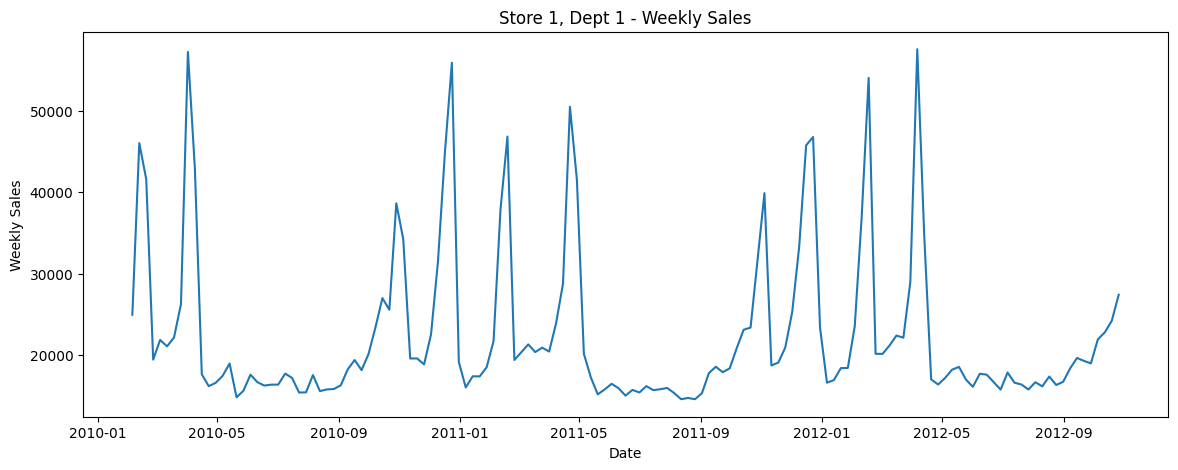

In [ ]:
series=train[(train['Store']==1) & (train['Dept']==1)].copy()   # We are checking whether the data is seasonal or not and picking the best plot as we dont noisy/flat data
series['Date']=pd.to_datetime(series['Date'])
series.sort_values('Date')

plt.figure(figsize=(14,5))
plt.plot(series['Date'],series['Weekly_Sales']) # The data is seasonal
plt.title('Store 1, Dept 1 - Weekly Sales')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.show()

## 3. Seasonal Decomposition
Decomposed the series into trend, seasonal, and residual components
(period=52, weekly data with yearly seasonality). Trend is largely flat
across the 3 years; seasonal component shows a strong, consistent yearly
cycle. Residuals are tight around zero except for sharp spikes around
April 2011 and April 2012 — later identified as likely tied to Easter,
whose date shifts annually and isn't captured by a fixed 52-week cycle.

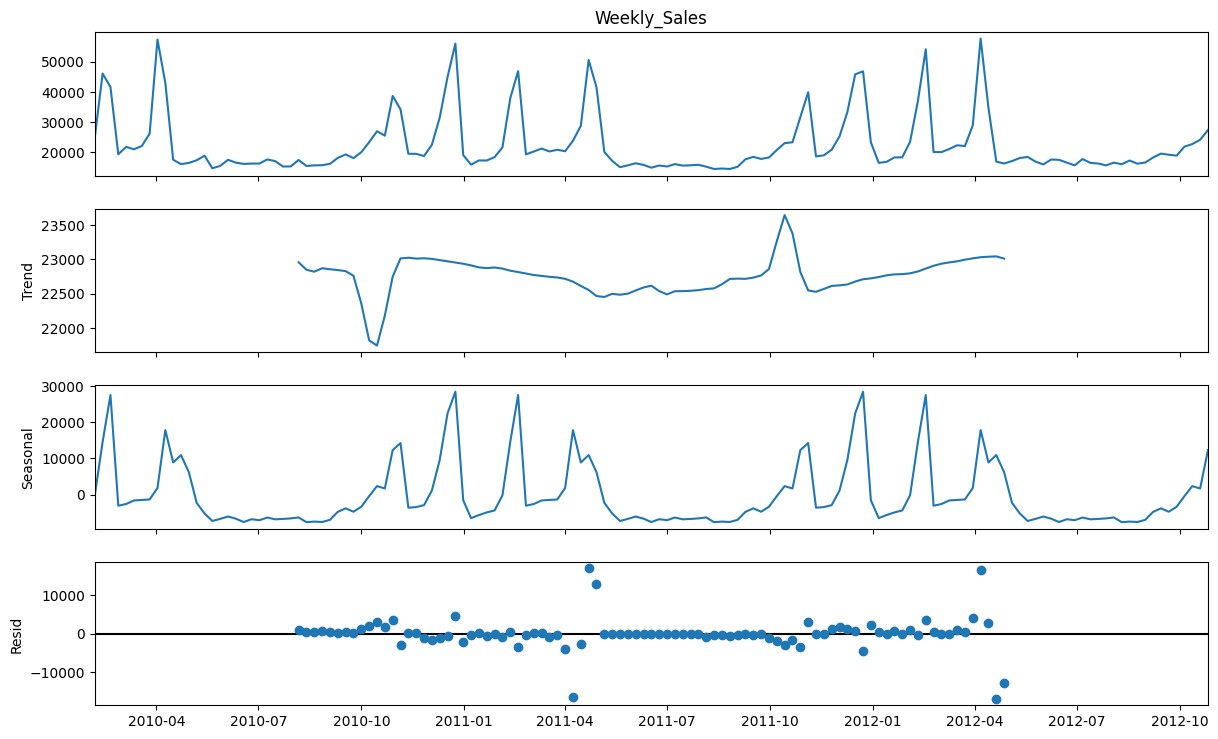

In [ ]:
series_indexed=series.set_index('Date')['Weekly_Sales']  # Setting date as index which is required for time-series data

result=seasonal_decompose(series_indexed,model='Additive',period=52) # It extracts trend,seasonal and residual part of the data
# Period=52 as there are 52 weeks in year as this is weekly data with yearly seasonality
# Additive model as seasonal variations stay roughly the same over time
fig=result.plot()
fig.set_size_inches(14,8)
plt.show() # The seasonal part is dominating here

## 4. Stationarity Testing (ADF)
Augmented Dickey-Fuller test on the original series returned a high
p-value, indicating non-stationarity — expected, given the strong
seasonal component observed above.

In [ ]:
# Now we will check whether the data is stationary(const mean/variance over time) or not coz sarima needs stationary data

result=adfuller(series_indexed)

print('ADF Statistics:',result[0])
print('P-value:',result[1])         # The data is not stationary so we will use seasonal differencing to make data stationary
print('Critical values:',result[4])

if result[1]<=0.05:
  print('The data is likely stationary(we reject null hypothesis)')
else:
  print('The data is not stationery(fail to reject null hypothesis)')


ADF Statistics: -2.5221638686500367
P-value: 0.11017432282586997
Critical values: {'1%': np.float64(-3.4793722137854926), '5%': np.float64(-2.8830370378332995), '10%': np.float64(-2.578233635380623)}
The data is not stationery(fail to reject null hypothesis)


## 5. Seasonal Differencing
Applied seasonal differencing (lag=52) to remove the yearly pattern.
Re-running the ADF test on the differenced series gave a p-value of
~1.2e-14, confirming stationarity. This sets the seasonal differencing
order D=1 for SARIMAX; regular differencing was not needed (d=0) since
the trend was already flat.

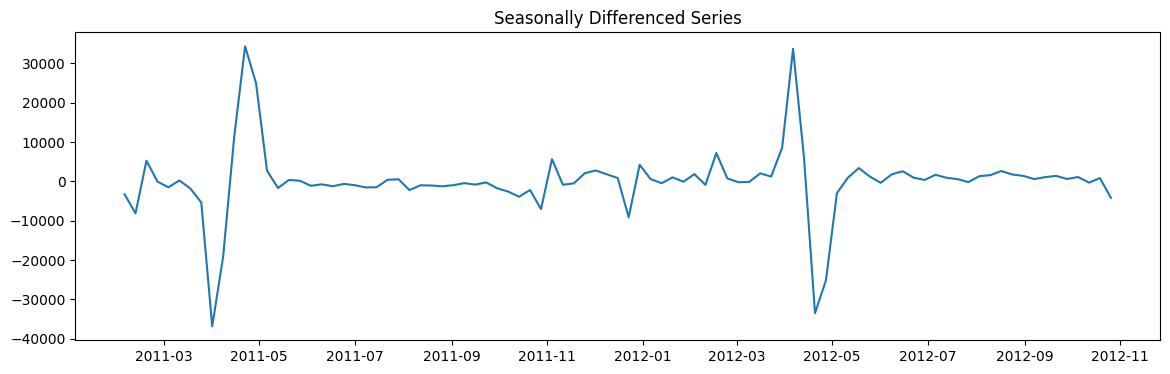

ADF Statistic: -8.892005631844732
p-value: 1.235262184661812e-14
Now stationary


In [ ]:
# Seasonal differencing (lag = 52 weeks) as this is weekly data
seasonal_diff = series_indexed.diff(52).dropna()

plt.figure(figsize=(14,4))
plt.plot(seasonal_diff)
plt.title('Seasonally Differenced Series')
plt.show()

# Re-run ADF test on the differenced series
result_diff = adfuller(seasonal_diff)
print('ADF Statistic:', result_diff[0])
print('p-value:', result_diff[1])

if result_diff[1] <= 0.05:   # We got D=1 as we did one time seasonal differencing and d=0 as seasonal differencing did the job
    print("Now stationary")
else:
    print("Still NOT stationary — may need regular (non-seasonal) differencing too")

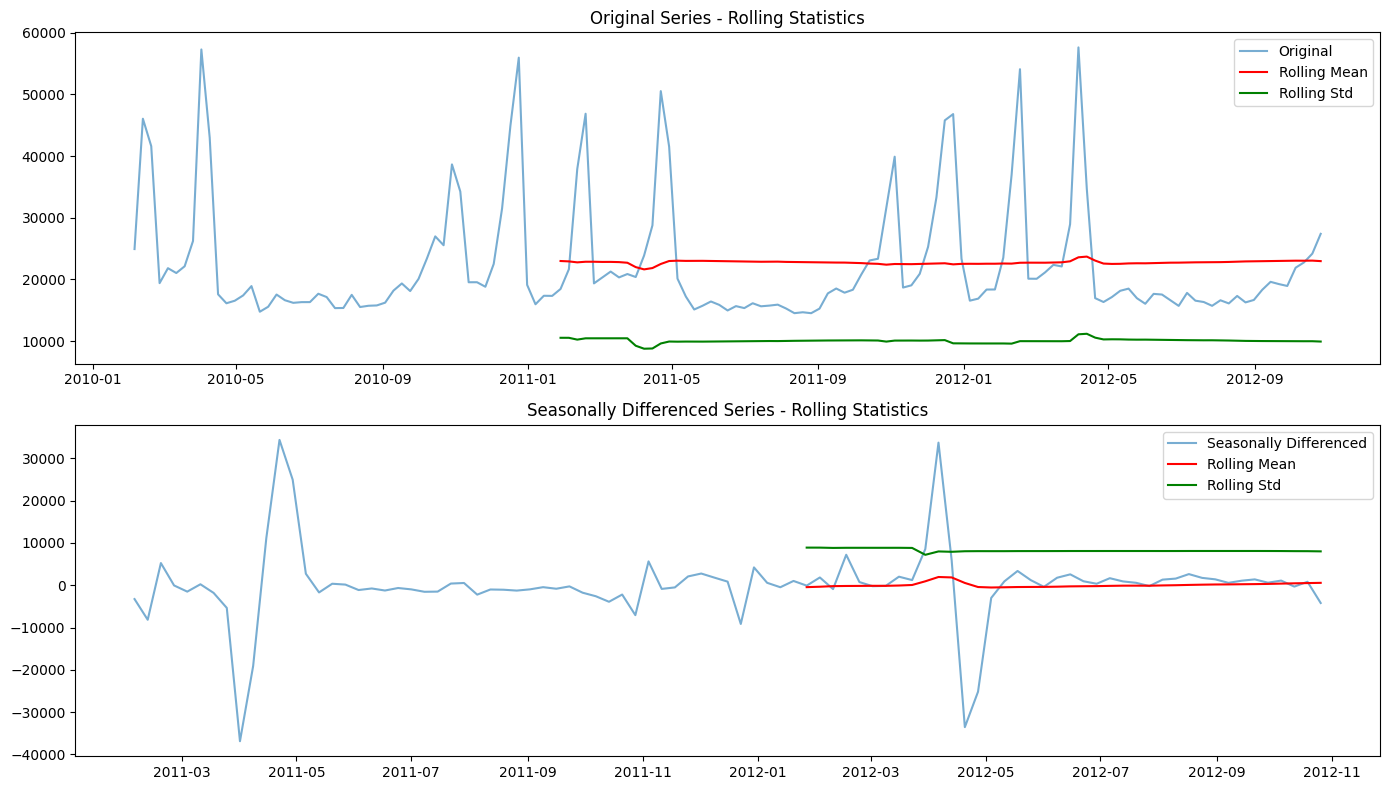

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Original series
rolling_mean_orig = series_indexed.rolling(window=52).mean()
rolling_std_orig = series_indexed.rolling(window=52).std()

axes[0].plot(series_indexed, label='Original', alpha=0.6)
axes[0].plot(rolling_mean_orig, label='Rolling Mean', color='red')
axes[0].plot(rolling_std_orig, label='Rolling Std', color='green')
axes[0].set_title('Original Series - Rolling Statistics')
axes[0].legend()

# Seasonally differenced series
rolling_mean_diff = seasonal_diff.rolling(window=52).mean()
rolling_std_diff = seasonal_diff.rolling(window=52).std()

axes[1].plot(seasonal_diff, label='Seasonally Differenced', alpha=0.6)
axes[1].plot(rolling_mean_diff, label='Rolling Mean', color='red')
axes[1].plot(rolling_std_diff, label='Rolling Std', color='green')
axes[1].set_title('Seasonally Differenced Series - Rolling Statistics')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. ACF/PACF Analysis
PACF shows a sharp cutoff after lag 2 (lags 1-2 significant, lag 3
onward within the confidence band) → suggests AR order p=2. ACF tapers
gradually rather than cutting off sharply, consistent with an AR process
rather than indicating an MA term → q=0. Seasonal lags near 52 couldn't
be directly inspected on PACF due to a sample-size constraint (max lag =
50% of series length), so seasonal AR/MA orders (P, Q) were set to 1 as
a starting point and validated via AIC comparison in the next section.

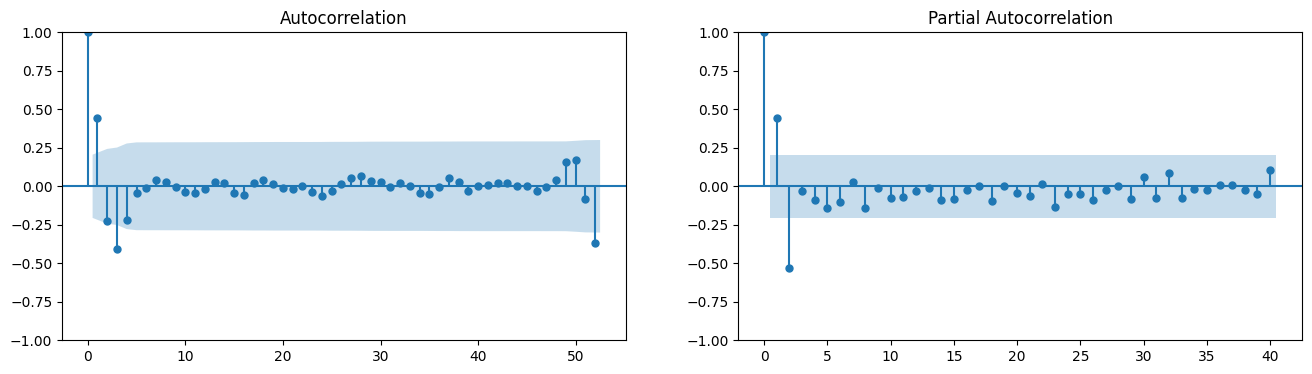

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# here PACF is used for p value(auto regressive part) like using past values to predict future
# PACF is like corelating y with y-3 without accounting anything in between whereas ACF is like corelation of y with y-1,y-2 and y-3
#ACF gives q value(moving average part) like how past errors terms are used in equation
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(seasonal_diff, lags=52, ax=axes[0])
plot_pacf(seasonal_diff, lags=40, ax=axes[1])
plt.show()
# Reading the PACF plot: lags 1 and 2 fall outside the shaded confidence
# band (statistically significant), lag 3 onward falls inside the band
# (not significant). Sharp cutoff after lag 2 in PACF -> suggests AR(2),
# so p = 2.

# ACF tapers off gradually rather than cutting off sharply, consistent
# with an AR-type process (confirms the PACF reading rather than
# suggesting its own MA term) -> q = 0.

# A residual spike near lag ~50 in ACF suggests some seasonal structure
# remains after one round of seasonal differencing -> use P=1, Q=1 as a
# starting guess for the seasonal terms (can't directly inspect lag 52
# due to sample size limits on PACF).

In [ ]:
train_size=len(series_indexed) - 20  # Keeping last 20 weeks for testing
train_data=series_indexed[:train_size]
test_data=series_indexed[train_size:]

print('Train:', train_data.shape, train_data.index.min(), 'to', train_data.index.max())
print('Test:', test_data.shape, test_data.index.min(), 'to', test_data.index.max())

Train: (123,) 2010-02-05 00:00:00 to 2012-06-08 00:00:00
Test: (20,) 2012-06-15 00:00:00 to 2012-10-26 00:00:00


## 7. SARIMAX — Parameter Selection & Model Comparison (AIC)
Compared SARIMAX(2,0,0)(1,1,1,52), (2,0,1)(1,1,1,52), and (1,0,0)(1,1,1,52)
using AIC. SARIMAX(2,0,0)(1,1,1,52) had the lowest AIC (359.44),
confirming the p=2, q=0 reading from the ACF/PACF plots.

In [ ]:
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Candidate parameter sets to compare
candidates = [
    (2,0,0,1,1,1,52),  # our main pick
    (2,0,1,1,1,1,52),  # add q=1, just to double check
    (1,0,0,1,1,1,52),  # simpler AR term
]
# Our main pick (p,d,q)=(2:pacf plot,0:no trend to remove,0:acf plot)
# (P,D,Q,S)=(1:starting guess,1:We did one time differencing,1:Starting guess,52:Length of one seasonal cycle)
results = {}
for p,d,q,P,D,Q,s in candidates:
    model = sm.tsa.SARIMAX(train_data, order=(p,d,q), seasonal_order=(P,D,Q,s),
                            enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False)
    results[(p,d,q,P,D,Q,s)] = fit.aic
    print(f'SARIMAX{(p,d,q)}x{(P,D,Q,s)} -> AIC: {fit.aic:.2f}') # Lower the AIC The better

best_params = min(results, key=results.get)
print('\nBest model:', best_params)

SARIMAX(2, 0, 0)x(1, 1, 1, 52) -> AIC: 359.44
SARIMAX(2, 0, 1)x(1, 1, 1, 52) -> AIC: 360.97
SARIMAX(1, 0, 0)x(1, 1, 1, 52) -> AIC: 383.99

Best model: (2, 0, 0, 1, 1, 1, 52)


In [ ]:
# Refit the winning model
best_model = sm.tsa.SARIMAX(train_data, order=(2,0,0), seasonal_order=(1,1,1,52),
                             enforce_stationarity=False, enforce_invertibility=False)
best_fit = best_model.fit(disp=False)

print(best_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                         Weekly_Sales   No. Observations:                  123
Model:             SARIMAX(2, 0, 0)x(1, 1, [1], 52)   Log Likelihood                -174.722
Date:                              Wed, 19 Aug 2026   AIC                            359.445
Time:                                      18:43:55   BIC                            363.611
Sample:                                  02-05-2010   HQIC                           359.859
                                       - 06-08-2012                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1925      0.224     -0.859      0.390      -0.632       0.247
ar.L2         -0.52

## 8. SARIMAX — Forecast & Evaluation
Initially evaluated on a 20-week held-out test set (MAPE: 5.90%), but
this window falls entirely within the low-seasonality period
of the year. Extended the test window to a full 52 weeks to include the
major seasonal peaks (Nov-Dec, Jan-Feb) for a more honest evaluation.



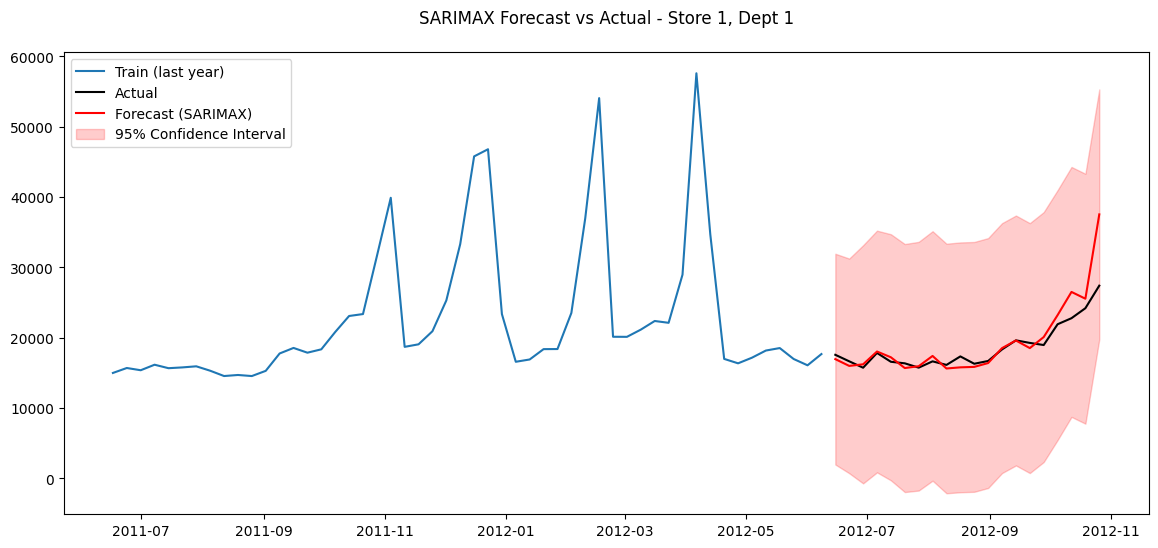

In [ ]:
# Forecast for the length of the test set, with confidence intervals
forecast_result = best_fit.get_forecast(steps=len(test_data))
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

# Plot: train (last portion), actual test, and forecast with CI
plt.figure(figsize=(14,6))
plt.plot(train_data[-52:], label='Train (last year)')
plt.plot(test_data, label='Actual', color='black')
plt.plot(forecast_mean, label='Forecast (SARIMAX)', color='red')
plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1],
                  color='red', alpha=0.2, label='95% Confidence Interval')
plt.legend()
plt.title(f'SARIMAX Forecast vs Actual - Store 1, Dept 1\n')
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import numpy as np

mape = mean_absolute_percentage_error(test_data, forecast_mean) * 100  # Average % difference between actual and forecasted values
rmse = np.sqrt(mean_squared_error(test_data, forecast_mean))   # Average error in same unit as original data(penalizes large error more than small ones)

print(f'SARIMAX MAPE: {mape:.2f}%') # On average,forecasts were off by 5.9% from actual weekly sales(industry benchmark is often 10-20% MAPE for this domain)
print(f'SARIMAX RMSE: {rmse:.2f}') # average error of ~$2,526 per week. Given weekly sales in this series range from ~15,000 to ~58,000, this represents a
                                  # relatively small error margin during a test window that stayed within baseline sales levels (no seasonal peaks in the test period)

SARIMAX MAPE: 5.90%
SARIMAX RMSE: 2525.80


# ~Forecasting for the entire year
Full-year result: MAPE 15.75%, RMSE 8053.25.

The model accurately forecasted two of three major peaks but significantly underforecast a spike in April 2012 — consistent with the Easter effect noted during decomposition. Since Easter's date shifts annually, a fixed 52-week seasonal model can't anticipate its exact timing, causing this single large miss.

In [ ]:
#Making the test data for whole year
train_size = len(series_indexed) - 52
train_data = series_indexed[:train_size]
test_data = series_indexed[train_size:]

print('Train:', train_data.shape, train_data.index.min(), 'to', train_data.index.max())
print('Test:', test_data.shape, test_data.index.min(), 'to', test_data.index.max())

Train: (91,) 2010-02-05 00:00:00 to 2011-10-28 00:00:00
Test: (52,) 2011-11-04 00:00:00 to 2012-10-26 00:00:00


MAPE: 15.75%
RMSE: 8053.25


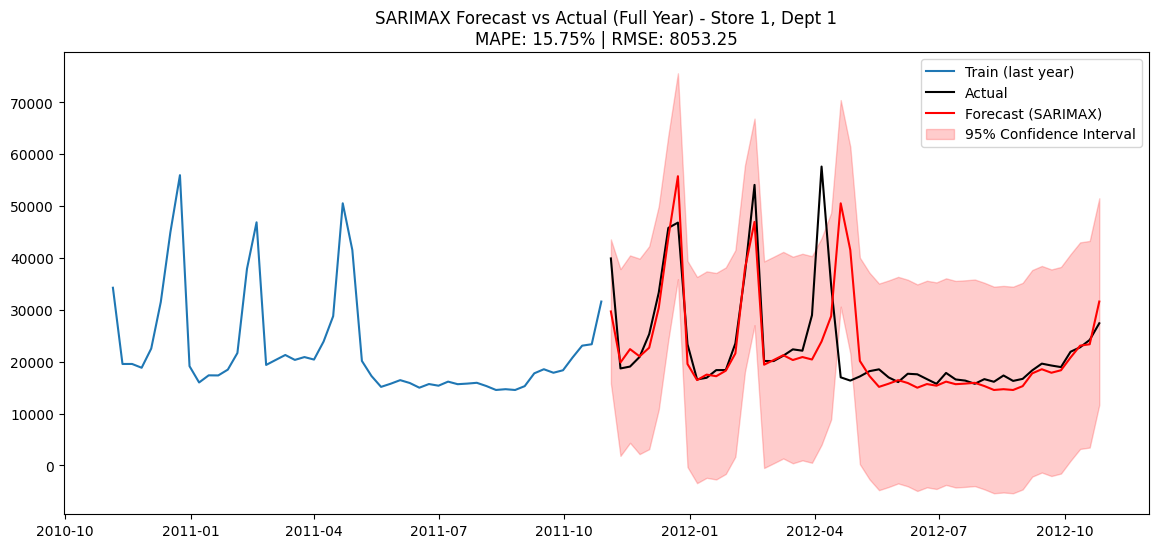

In [ ]:
best_model = sm.tsa.SARIMAX(train_data, order=(2,0,0), seasonal_order=(1,1,1,52),
                             enforce_stationarity=False, enforce_invertibility=False)
best_fit = best_model.fit(disp=False)

forecast_result = best_fit.get_forecast(steps=len(test_data))
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

mape = mean_absolute_percentage_error(test_data, forecast_mean) * 100
rmse = np.sqrt(mean_squared_error(test_data, forecast_mean))
print(f'MAPE: {mape:.2f}%')
print(f'RMSE: {rmse:.2f}')

plt.figure(figsize=(14,6))
plt.plot(train_data[-52:], label='Train (last year)')
plt.plot(test_data, label='Actual', color='black')
plt.plot(forecast_mean, label='Forecast (SARIMAX)', color='red')
plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1],
                  color='red', alpha=0.2, label='95% Confidence Interval')
plt.legend()
plt.title(f'SARIMAX Forecast vs Actual (Full Year) - Store 1, Dept 1\nMAPE: {mape:.2f}% | RMSE: {rmse:.2f}')
plt.show()

## 9. Prophet — Model & Evaluation
Fit Prophet with US holiday awareness enabled (`add_country_holidays`),
specifically to test whether explicit holiday-handling could address
the Easter miss seen in SARIMAX.

**Result: MAPE 23.29%, RMSE 7555.32**

Prophet correctly identified the timing of all three seasonal peaks,
including the Easter-related one that SARIMAX missed — but consistently
underestimated peak magnitude across all three. This is likely due to
limited training history (~2 years), giving Prophet only 1-2 examples of
the holiday pattern to learn from. Switching seasonality modes had
minimal effect, suggesting the underestimation stems more from data
quantity than from seasonality-mode misspecification.

In [ ]:
!pip install prophet -q # Prophet isn't preinstalled in Colab, so we install it here

from prophet import Prophet

# Prophet requires a dataframe with 'ds' (date) and 'y' (value) columns
prophet_train = train_data.reset_index()
prophet_train.columns = ['ds', 'y']

prophet_train.head()

,ds,y
0,2010-02-05,24924.50
1,2010-02-12,46039.49
2,2010-02-19,41595.55
3,2010-02-26,19403.54
4,2010-03-05,21827.90


In [ ]:
model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model_prophet.add_country_holidays(country_name='US')
model_prophet.fit(prophet_train)

In [ ]:
future = model_prophet.make_future_dataframe(periods=len(test_data), freq='W')
forecast = model_prophet.predict(future)

# Extract just the forecasted portion matching our test set
prophet_forecast = forecast.set_index('ds')['yhat'][-len(test_data):]

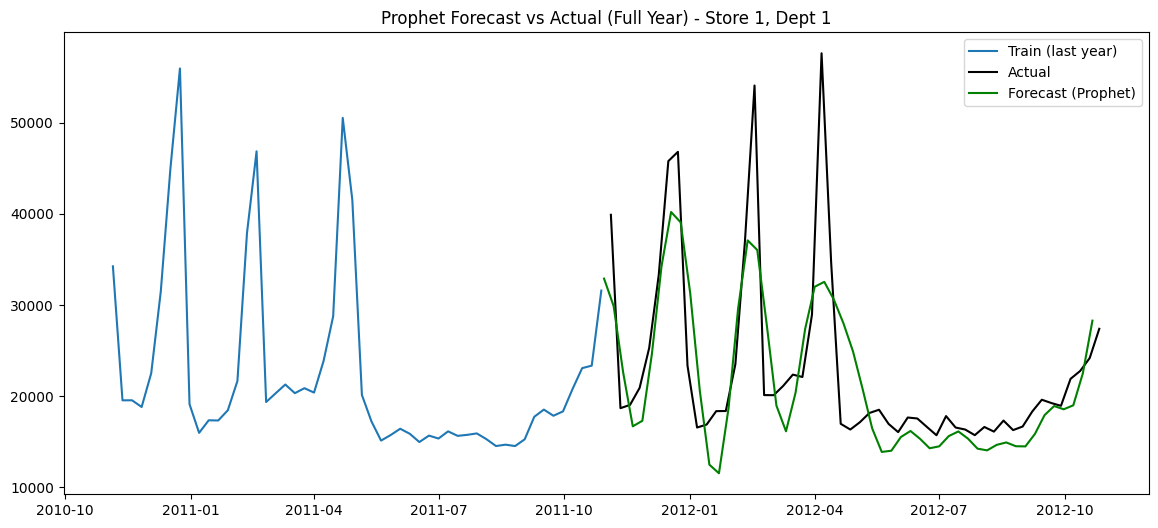

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(train_data[-52:], label='Train (last year)')
plt.plot(test_data, label='Actual', color='black')
plt.plot(prophet_forecast, label='Forecast (Prophet)', color='green')
plt.legend()
plt.title('Prophet Forecast vs Actual (Full Year) - Store 1, Dept 1')
plt.show()

### 10. Model Comparison & Key Findings

| Model | MAPE | RMSE |
|---|---|---|
| SARIMAX(2,0,0)(1,1,1,52) | 15.75% | 8053.25 |
| Prophet (holiday-aware) | 23.29% | 7555.32 |

**Key finding:** SARIMAX achieved lower average error but was fragile to
a single calendar-shifting holiday event (Easter), causing one large
miss that inflated its RMSE. Prophet's built-in holiday-awareness caught
the *timing* of that same event, but underestimated its *magnitude* —
likely due to limited training history (~2 years, meaning the model saw
this holiday pattern only 1-2 times).

This reflects a genuine trade-off rather than one model being
objectively superior: SARIMAX is highly accurate under stable,
repeating conditions but fragile to irregular calendar effects, while
Prophet trades some baseline precision for better robustness to
holidays — a trade-off that would likely shift further in Prophet's
favor with more historical training data.

**Limitations:**
- Single series (Store 1, Dept 1) — not yet validated across multiple
  stores/departments
- ~2 years of training data limits how well holiday effects can be learned
- External regressors (markdowns, CPI, unemployment from features.csv)
  were not used in this iteration — a natural next step for SARIMAX's
  "X" (exogenous) component

In [32]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error


mape_prophet = mean_absolute_percentage_error(test_data, prophet_forecast) * 100
rmse_prophet = np.sqrt(mean_squared_error(test_data, prophet_forecast))

print(f'Prophet MAPE: {mape_prophet:.2f}%')
print(f'Prophet RMSE: {rmse_prophet:.2f}')

print(f'\n--- Comparison ---')
print(f'SARIMAX -> MAPE: 15.75%, RMSE: 8053.25')
print(f'Prophet -> MAPE: {mape_prophet:.2f}%, RMSE: {rmse_prophet:.2f}')

Prophet MAPE: 23.48%
Prophet RMSE: 7561.68

--- Comparison ---
SARIMAX -> MAPE: 15.75%, RMSE: 8053.25
Prophet -> MAPE: 23.48%, RMSE: 7561.68
